# Linear Regression Lab — Predicting Network Latency

## Objective

Use linear regression to predict **Round-Trip Time (RTT)** from traceroute measurements:
- **Hop count** — number of routers traversed
- **Geographic distance** — physical distance between source and destination (km)
- **Time of day** — hour of measurement (affects congestion)

## Learning Goals

1. Understand the physical intuition behind linear regression in networking
2. Build a single-feature model (hops → RTT)
3. Build a multi-feature model (hops + distance + hour → RTT)
4. Evaluate and compare models using MSE, RMSE, and R²
5. Interpret model coefficients in networking terms

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Generate Synthetic Traceroute Dataset

We simulate realistic traceroute measurements based on networking physics:

- Each hop adds ~2–5 ms of processing/queuing delay
- Distance adds propagation delay (~0.005 ms/km via fibre at 2/3 speed of light)
- Peak hours (9–18) add congestion delay
- Random jitter from queuing variability

In [2]:
n_samples = 1000

# Features
hops = np.random.randint(3, 25, n_samples)  # 3 to 24 hops
distance_km = np.random.uniform(50, 15000, n_samples)  # 50 km to 15000 km
hour = np.random.randint(0, 24, n_samples)  # 0-23 hour of day

# Derived: is it peak hours? (business hours have more congestion)
is_peak = ((hour >= 9) & (hour <= 18)).astype(float)

# RTT model (ground truth with noise)
# Each hop: ~3.5 ms base delay
# Distance: ~0.005 ms per km (propagation in fibre)
# Peak hour: adds ~8-15 ms on average (congestion)
# Noise: random jitter (queuing variability)
rtt = (
    3.5 * hops                          # per-hop delay
    + 0.005 * distance_km               # propagation delay
    + 12 * is_peak                      # congestion during business hours
    + 0.8 * hops * is_peak              # more hops = more congestion impact
    + np.random.normal(0, 8, n_samples) # jitter/noise
    + 5                                 # base processing overhead
)

# Ensure RTT is positive (clip at 1 ms minimum)
rtt = np.maximum(rtt, 1.0)

# Create DataFrame
df = pd.DataFrame({
    "hops": hops,
    "distance_km": distance_km.round(1),
    "hour": hour,
    "is_peak": is_peak.astype(int),
    "rtt_ms": rtt.round(2)
})

print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (1000, 5)


,hops,distance_km,hour,is_peak,rtt_ms
0,9,5056.8,17,1,72.20
1,22,2132.1,12,1,119.37
2,17,11920.7,20,0,109.67
3,13,9320.1,20,0,94.26
4,10,8025.2,17,1,99.38
5,23,13413.7,4,0,154.40
6,9,11839.5,12,1,116.81
7,21,2317.5,3,0,97.32
8,13,4710.2,16,1,84.13
9,13,3764.9,2,0,57.43


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.describe().round(2)

,hops,distance_km,hour,is_peak,rtt_ms
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,13.23,7517.51,11.78,0.40,97.74
std,6.54,4372.27,7.00,0.49,36.07
min,3.00,119.20,0.00,0.00,16.57
25%,7.00,3543.60,6.00,0.00,71.12
50%,13.00,7625.00,12.00,0.00,97.37
75%,19.00,11193.32,18.00,1.00,122.41
max,24.00,14991.20,23.00,1.00,202.26


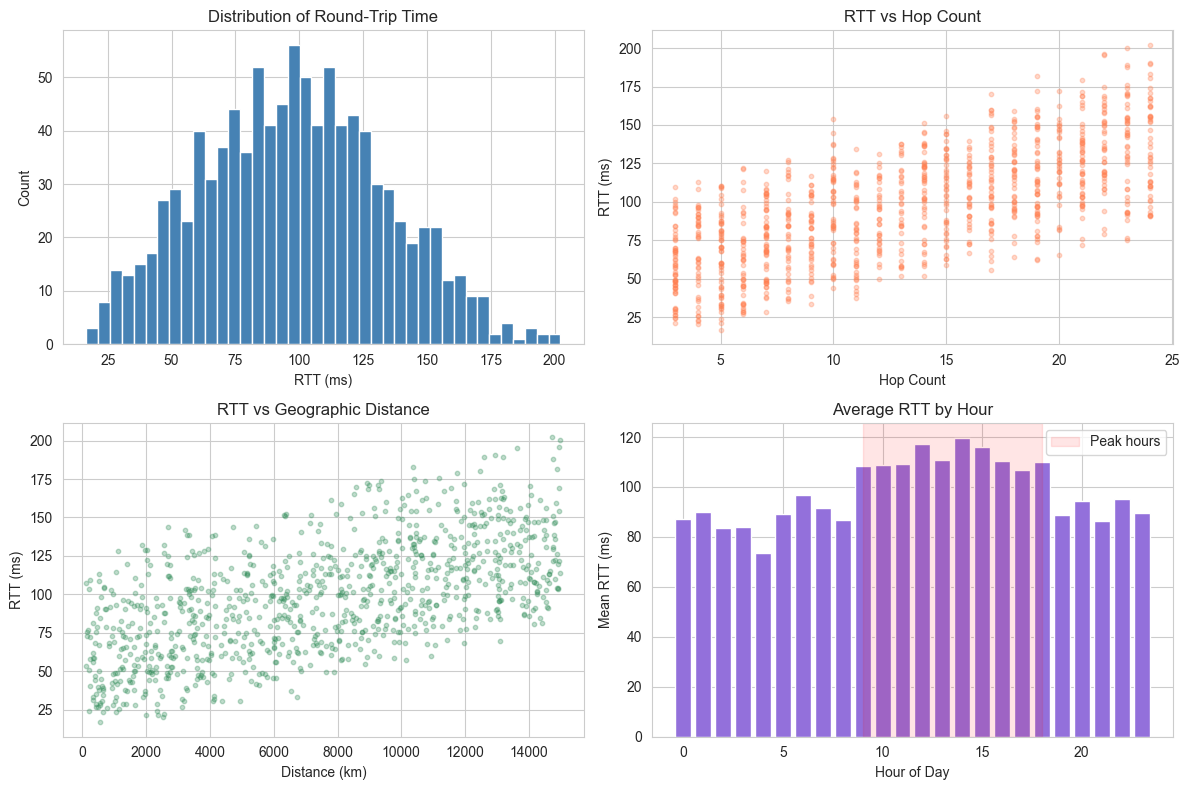

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Distribution of RTT
axes[0, 0].hist(df["rtt_ms"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_xlabel("RTT (ms)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of Round-Trip Time")

# RTT vs Hops
axes[0, 1].scatter(df["hops"], df["rtt_ms"], alpha=0.3, s=10, color="coral")
axes[0, 1].set_xlabel("Hop Count")
axes[0, 1].set_ylabel("RTT (ms)")
axes[0, 1].set_title("RTT vs Hop Count")

# RTT vs Distance
axes[1, 0].scatter(df["distance_km"], df["rtt_ms"], alpha=0.3, s=10, color="seagreen")
axes[1, 0].set_xlabel("Distance (km)")
axes[1, 0].set_ylabel("RTT (ms)")
axes[1, 0].set_title("RTT vs Geographic Distance")

# RTT by time of day
hourly_rtt = df.groupby("hour")["rtt_ms"].mean()
axes[1, 1].bar(hourly_rtt.index, hourly_rtt.values, color="mediumpurple", edgecolor="white")
axes[1, 1].axvspan(9, 18, alpha=0.1, color="red", label="Peak hours")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("Mean RTT (ms)")
axes[1, 1].set_title("Average RTT by Hour")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

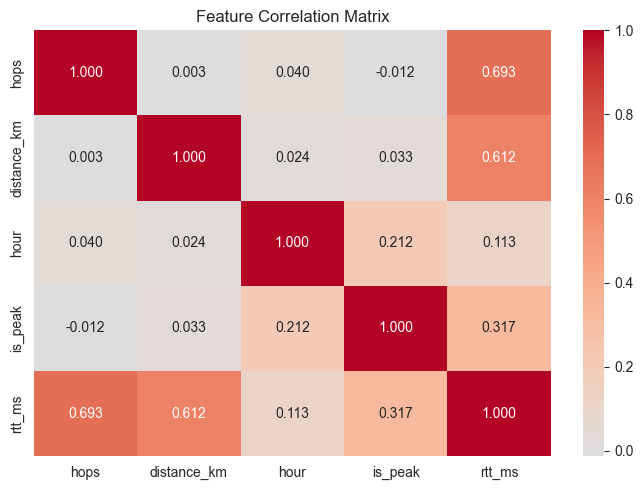


Correlation with RTT:
hops           0.693288
distance_km    0.611867
is_peak        0.316566
hour           0.113170
Name: rtt_ms, dtype: float64


In [5]:
# Correlation matrix
corr = df[["hops", "distance_km", "hour", "is_peak", "rtt_ms"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".3f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with RTT:")
print(corr["rtt_ms"].drop("rtt_ms").sort_values(ascending=False))

## 4. Train/Test Split

In [6]:
# Target
y = df["rtt_ms"]

# Features (we'll use different subsets for comparison)
X_hops_only = df[["hops"]]                             # Single feature
X_multi = df[["hops", "distance_km", "is_peak"]]       # Multi-feature

# Split (80% train, 20% test)
X_hops_train, X_hops_test, y_train, y_test = train_test_split(
    X_hops_only, y, test_size=0.2, random_state=42
)
X_multi_train, X_multi_test, _, _ = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(y_train)}")
print(f"Test samples:     {len(y_test)}")

Training samples: 800
Test samples:     200


## 5. Model 1 — Single-Feature Linear Regression (Hops Only)

$$\hat{\text{RTT}} = w \times \text{hops} + b$$

**Question:** How much does each additional hop add to the RTT?

In [7]:
# Train single-feature model
model_single = LinearRegression()
model_single.fit(X_hops_train, y_train)

# Coefficients
w = model_single.coef_[0]
b = model_single.intercept_

print("=== Single-Feature Model (Hops → RTT) ===")
print(f"\nEquation: RTT = {w:.2f} × hops + {b:.2f}")
print(f"\nInterpretation:")
print(f"  • Each additional hop adds ~{w:.2f} ms to RTT")
print(f"  • Base latency (0 hops): ~{b:.2f} ms")

=== Single-Feature Model (Hops → RTT) ===

Equation: RTT = 3.78 × hops + 47.71

Interpretation:
  • Each additional hop adds ~3.78 ms to RTT
  • Base latency (0 hops): ~47.71 ms


In [8]:
# Predictions and evaluation
y_pred_single = model_single.predict(X_hops_test)

mse_single = mean_squared_error(y_test, y_pred_single)
rmse_single = np.sqrt(mse_single)
mae_single = mean_absolute_error(y_test, y_pred_single)
r2_single = r2_score(y_test, y_pred_single)

print("=== Model 1 Evaluation (Test Set) ===")
print(f"  MSE:  {mse_single:.2f} ms²")
print(f"  RMSE: {rmse_single:.2f} ms")
print(f"  MAE:  {mae_single:.2f} ms")
print(f"  R²:   {r2_single:.4f}")
print(f"\n  → The model explains {r2_single*100:.1f}% of RTT variance using hops alone.")

=== Model 1 Evaluation (Test Set) ===
  MSE:  628.09 ms²
  RMSE: 25.06 ms
  MAE:  20.82 ms
  R²:   0.5097

  → The model explains 51.0% of RTT variance using hops alone.


/Users/pnivaggi/dev/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


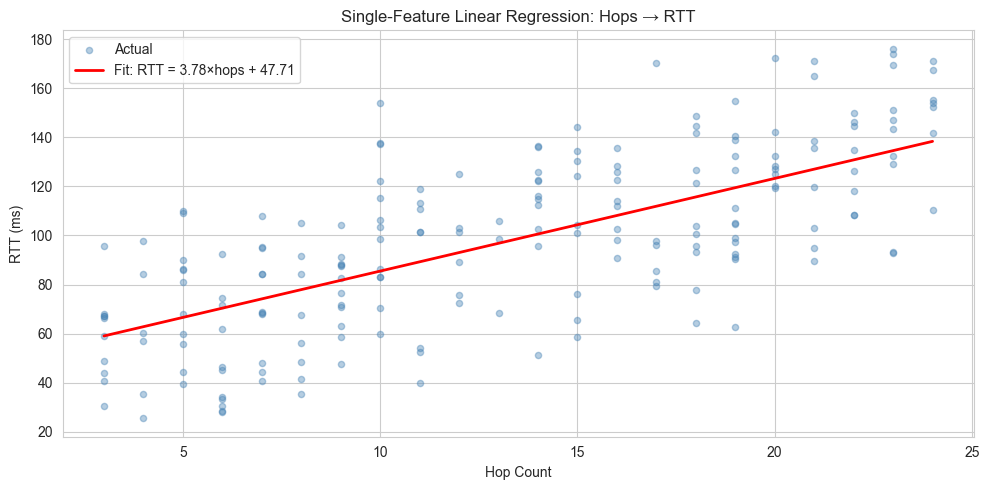

In [9]:
# Visualise: regression line
plt.figure(figsize=(10, 5))

plt.scatter(X_hops_test["hops"], y_test, alpha=0.4, s=20, label="Actual", color="steelblue")

# Plot regression line
x_line = np.linspace(3, 24, 100).reshape(-1, 1)
y_line = model_single.predict(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"Fit: RTT = {w:.2f}×hops + {b:.2f}")

plt.xlabel("Hop Count")
plt.ylabel("RTT (ms)")
plt.title("Single-Feature Linear Regression: Hops → RTT")
plt.legend()
plt.tight_layout()
plt.show()

### Observations on Model 1

The scatter shows significant **vertical spread** around the regression line — hops alone don't fully explain RTT. The remaining variance comes from:
- Geographic distance (propagation delay)
- Time of day (congestion)
- Random jitter

Let's add more features!

## 6. Model 2 — Multi-Feature Linear Regression

$$\hat{\text{RTT}} = w_1 \times \text{hops} + w_2 \times \text{distance\_km} + w_3 \times \text{is\_peak} + b$$

In [10]:
# Train multi-feature model
model_multi = LinearRegression()
model_multi.fit(X_multi_train, y_train)

# Coefficients
feature_names = X_multi.columns.tolist()
coefs = dict(zip(feature_names, model_multi.coef_))

print("=== Multi-Feature Model ===")
print(f"\nEquation: RTT = ", end="")
terms = [f"{coefs[f]:.4f}×{f}" for f in feature_names]
print(" + ".join(terms) + f" + {model_multi.intercept_:.2f}")

print(f"\nCoefficient Interpretation:")
print(f"  • hops:        +{coefs['hops']:.2f} ms per additional hop")
print(f"  • distance_km: +{coefs['distance_km']:.4f} ms per km (≈{coefs['distance_km']*1000:.2f} ms per 1000 km)")
print(f"  • is_peak:     +{coefs['is_peak']:.2f} ms during business hours")
print(f"  • intercept:   {model_multi.intercept_:.2f} ms (base overhead)")

=== Multi-Feature Model ===

Equation: RTT = 3.8242×hops + 0.0050×distance_km + 22.4228×is_peak + 0.77

Coefficient Interpretation:
  • hops:        +3.82 ms per additional hop
  • distance_km: +0.0050 ms per km (≈4.97 ms per 1000 km)
  • is_peak:     +22.42 ms during business hours
  • intercept:   0.77 ms (base overhead)


In [11]:
# Predictions and evaluation
y_pred_multi = model_multi.predict(X_multi_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("=== Model 2 Evaluation (Test Set) ===")
print(f"  MSE:  {mse_multi:.2f} ms²")
print(f"  RMSE: {rmse_multi:.2f} ms")
print(f"  MAE:  {mae_multi:.2f} ms")
print(f"  R²:   {r2_multi:.4f}")
print(f"\n  → The model explains {r2_multi*100:.1f}% of RTT variance.")

=== Model 2 Evaluation (Test Set) ===
  MSE:  73.45 ms²
  RMSE: 8.57 ms
  MAE:  6.78 ms
  R²:   0.9427

  → The model explains 94.3% of RTT variance.


## 7. Model Comparison

In [12]:
# Comparison table
comparison = pd.DataFrame({
    "Model": ["Single (hops only)", "Multi (hops + distance + peak)"],
    "MSE (ms²)": [mse_single, mse_multi],
    "RMSE (ms)": [rmse_single, rmse_multi],
    "MAE (ms)": [mae_single, mae_multi],
    "R²": [r2_single, r2_multi],
}).round(4)

print("=== Model Comparison ===")
print(comparison.to_string(index=False))

improvement = (1 - mse_multi / mse_single) * 100
print(f"\n→ Multi-feature model reduces MSE by {improvement:.1f}%")
print(f"→ R² improved from {r2_single:.3f} to {r2_multi:.3f}")

=== Model Comparison ===
                         Model  MSE (ms²)  RMSE (ms)  MAE (ms)     R²
            Single (hops only)   628.0939    25.0618   20.8196 0.5097
Multi (hops + distance + peak)    73.4537     8.5705    6.7841 0.9427

→ Multi-feature model reduces MSE by 88.3%
→ R² improved from 0.510 to 0.943


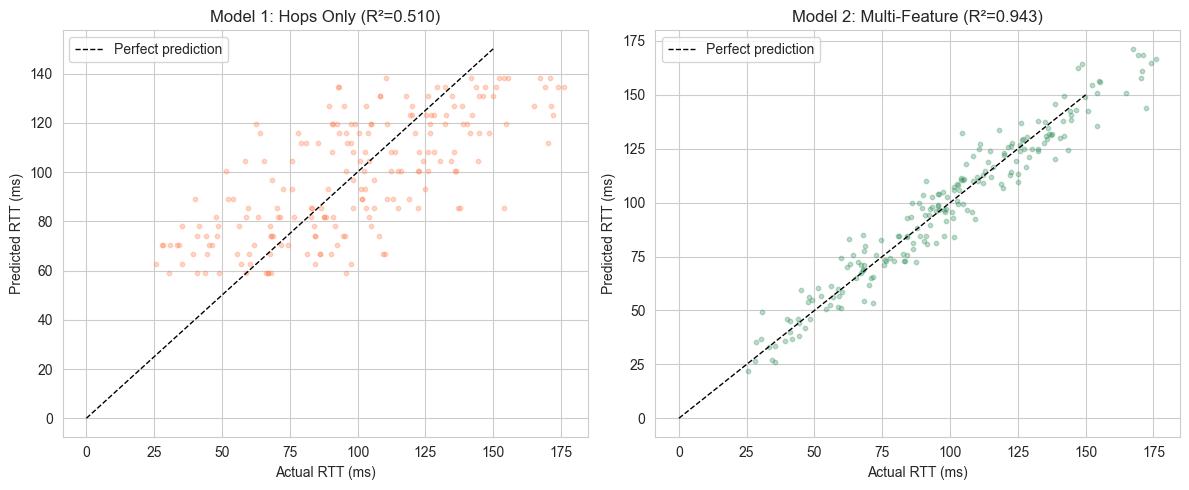

In [13]:
# Visual comparison: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Model 1
axes[0].scatter(y_test, y_pred_single, alpha=0.3, s=10, color="coral")
axes[0].plot([0, 150], [0, 150], "k--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual RTT (ms)")
axes[0].set_ylabel("Predicted RTT (ms)")
axes[0].set_title(f"Model 1: Hops Only (R²={r2_single:.3f})")
axes[0].legend()

# Model 2
axes[1].scatter(y_test, y_pred_multi, alpha=0.3, s=10, color="seagreen")
axes[1].plot([0, 150], [0, 150], "k--", linewidth=1, label="Perfect prediction")
axes[1].set_xlabel("Actual RTT (ms)")
axes[1].set_ylabel("Predicted RTT (ms)")
axes[1].set_title(f"Model 2: Multi-Feature (R²={r2_multi:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Residual Analysis

Residuals = Actual − Predicted. A good model should have residuals:
- Centred around 0
- Randomly scattered (no patterns)
- Approximately normally distributed

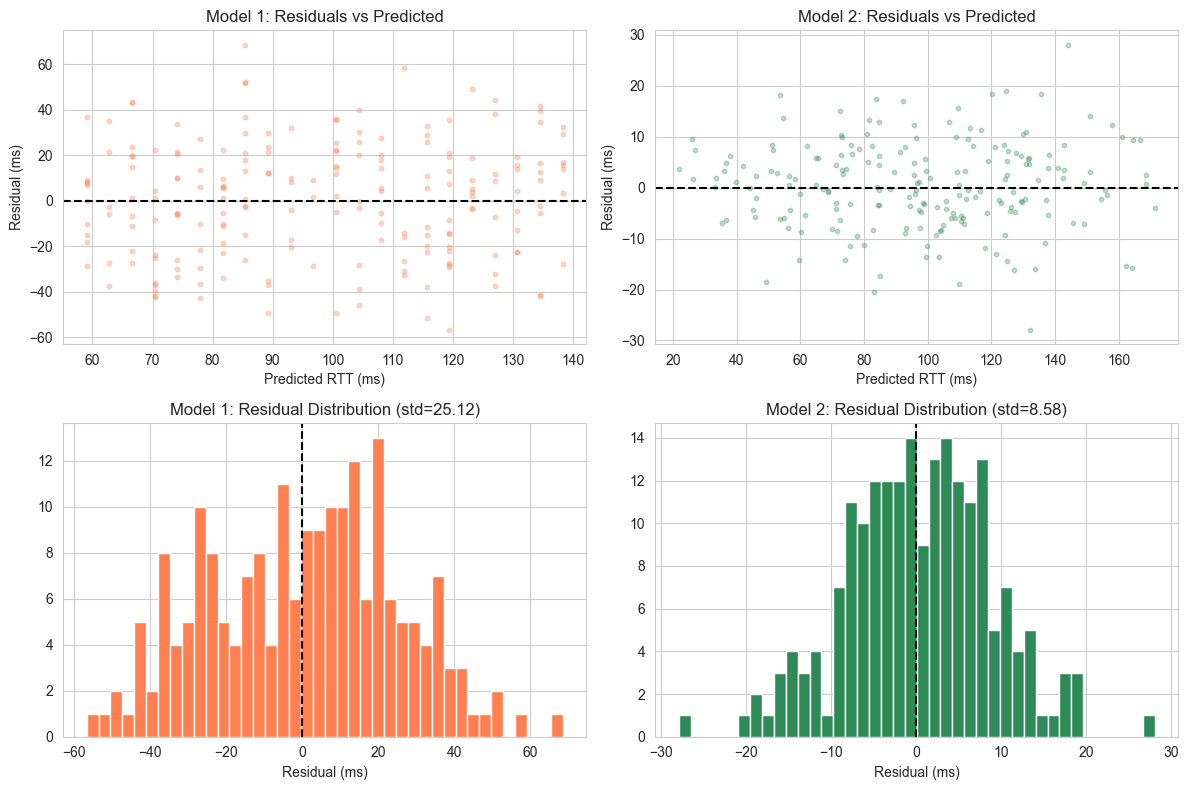

In [14]:
residuals_single = y_test - y_pred_single
residuals_multi = y_test - y_pred_multi

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals vs predicted (Model 1)
axes[0, 0].scatter(y_pred_single, residuals_single, alpha=0.3, s=10, color="coral")
axes[0, 0].axhline(y=0, color="black", linestyle="--")
axes[0, 0].set_xlabel("Predicted RTT (ms)")
axes[0, 0].set_ylabel("Residual (ms)")
axes[0, 0].set_title("Model 1: Residuals vs Predicted")

# Residuals vs predicted (Model 2)
axes[0, 1].scatter(y_pred_multi, residuals_multi, alpha=0.3, s=10, color="seagreen")
axes[0, 1].axhline(y=0, color="black", linestyle="--")
axes[0, 1].set_xlabel("Predicted RTT (ms)")
axes[0, 1].set_ylabel("Residual (ms)")
axes[0, 1].set_title("Model 2: Residuals vs Predicted")

# Residual distributions
axes[1, 0].hist(residuals_single, bins=40, color="coral", edgecolor="white")
axes[1, 0].axvline(x=0, color="black", linestyle="--")
axes[1, 0].set_xlabel("Residual (ms)")
axes[1, 0].set_title(f"Model 1: Residual Distribution (std={residuals_single.std():.2f})")

axes[1, 1].hist(residuals_multi, bins=40, color="seagreen", edgecolor="white")
axes[1, 1].axvline(x=0, color="black", linestyle="--")
axes[1, 1].set_xlabel("Residual (ms)")
axes[1, 1].set_title(f"Model 2: Residual Distribution (std={residuals_multi.std():.2f})")

plt.tight_layout()
plt.show()

## 9. Cross-Validation

In [15]:
# 5-fold cross-validation
cv_single = cross_val_score(LinearRegression(), X_hops_only, y, cv=5, scoring="r2")
cv_multi = cross_val_score(LinearRegression(), X_multi, y, cv=5, scoring="r2")

print("=== 5-Fold Cross-Validation (R² scores) ===")
print(f"\nModel 1 (hops only):  {cv_single.mean():.4f} ± {cv_single.std():.4f}")
print(f"  Folds: {[f'{s:.4f}' for s in cv_single]}")
print(f"\nModel 2 (multi):      {cv_multi.mean():.4f} ± {cv_multi.std():.4f}")
print(f"  Folds: {[f'{s:.4f}' for s in cv_multi]}")
print(f"\n→ Cross-validation confirms Model 2 is consistently better.")

=== 5-Fold Cross-Validation (R² scores) ===

Model 1 (hops only):  0.4766 ± 0.0390
  Folds: ['0.4644', '0.5237', '0.4386', '0.5215', '0.4345']

Model 2 (multi):      0.9448 ± 0.0039
  Folds: ['0.9482', '0.9492', '0.9396', '0.9462', '0.9407']

→ Cross-validation confirms Model 2 is consistently better.


## 10. Feature Importance via Coefficient Magnitude

To compare coefficients fairly, we need to standardise features (mean=0, std=1).

=== Feature Importance (Standardised Coefficients) ===
    Feature  Raw Coefficient  Standardised Coefficient  |Standardised|
       hops         3.824208                 25.065081       25.065081
distance_km         0.004968                 21.624316       21.624316
    is_peak        22.422809                 11.010122       11.010122


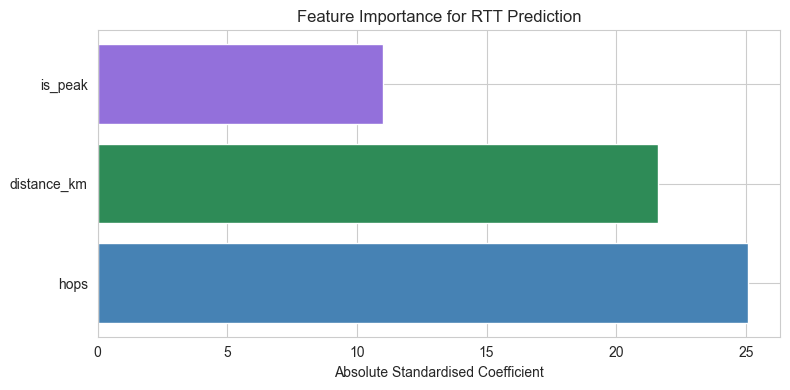

In [16]:
# Standardised coefficients for fair comparison
scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi)

model_scaled = LinearRegression()
model_scaled.fit(X_multi_scaled, y)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Raw Coefficient": model_multi.coef_,
    "Standardised Coefficient": model_scaled.coef_,
    "|Standardised|": np.abs(model_scaled.coef_),
}).sort_values("|Standardised|", ascending=False)

print("=== Feature Importance (Standardised Coefficients) ===")
print(importance.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 4))
colors = ["steelblue", "seagreen", "mediumpurple"]
plt.barh(importance["Feature"], importance["|Standardised|"], color=colors)
plt.xlabel("Absolute Standardised Coefficient")
plt.title("Feature Importance for RTT Prediction")
plt.tight_layout()
plt.show()

## 11. Practical Predictions

Use the model to predict RTT for specific network paths.

In [17]:
# Predict RTT for realistic scenarios
scenarios = pd.DataFrame({
    "Scenario": [
        "Local data centre (same city)",
        "Regional (Paris → London)",
        "Continental (Paris → Moscow)",
        "Intercontinental (Paris → Tokyo)",
        "Same region, peak hours",
        "Same region, off-peak",
    ],
    "hops": [4, 8, 14, 20, 8, 8],
    "distance_km": [50, 350, 2500, 9700, 350, 350],
    "is_peak": [0, 0, 0, 0, 1, 0],
})

X_scenarios = scenarios[["hops", "distance_km", "is_peak"]]
scenarios["Predicted RTT (ms)"] = model_multi.predict(X_scenarios).round(1)

print("=== RTT Predictions for Network Paths ===")
print(scenarios[["Scenario", "hops", "distance_km", "is_peak", "Predicted RTT (ms)"]].to_string(index=False))

=== RTT Predictions for Network Paths ===
                        Scenario  hops  distance_km  is_peak  Predicted RTT (ms)
   Local data centre (same city)     4           50        0                16.3
       Regional (Paris → London)     8          350        0                33.1
    Continental (Paris → Moscow)    14         2500        0                66.7
Intercontinental (Paris → Tokyo)    20         9700        0               125.4
         Same region, peak hours     8          350        1                55.5
           Same region, off-peak     8          350        0                33.1


## 12. Limitations of Linear Regression for Network Latency

Let's explore where the linear model breaks down.

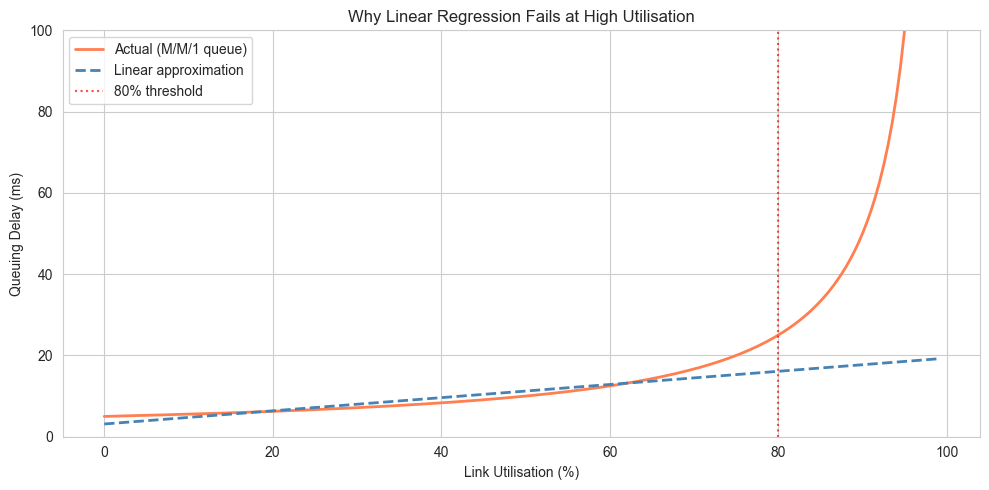

Key Insight: Network latency becomes NON-LINEAR when links approach saturation.
Linear regression works well for normal conditions but fails at extremes.

Possible improvements:
  • Add polynomial features (hops², distance²)
  • Use a non-linear model (decision tree, random forest)
  • Segment by utilisation level and fit separate models


In [18]:
# Simulate non-linear behaviour: congestion spikes at high utilisation
# Real networks show exponential latency growth when utilisation > 80%

utilisation = np.linspace(0, 0.99, 200)
# M/M/1 queuing model: delay ~ 1/(1 - utilisation)
queuing_delay = 5 / (1 - utilisation)

plt.figure(figsize=(10, 5))
plt.plot(utilisation * 100, queuing_delay, color="coral", linewidth=2, label="Actual (M/M/1 queue)")

# What linear regression would predict
from numpy.polynomial import polynomial as P
linear_fit = np.polyfit(utilisation[:150], queuing_delay[:150], 1)  # fit on 0-75%
linear_pred = np.polyval(linear_fit, utilisation)
plt.plot(utilisation * 100, linear_pred, "--", color="steelblue", linewidth=2, label="Linear approximation")

plt.axvline(x=80, color="red", linestyle=":", alpha=0.7, label="80% threshold")
plt.xlabel("Link Utilisation (%)")
plt.ylabel("Queuing Delay (ms)")
plt.title("Why Linear Regression Fails at High Utilisation")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

print("Key Insight: Network latency becomes NON-LINEAR when links approach saturation.")
print("Linear regression works well for normal conditions but fails at extremes.")
print("\nPossible improvements:")
print("  • Add polynomial features (hops², distance²)")
print("  • Use a non-linear model (decision tree, random forest)")
print("  • Segment by utilisation level and fit separate models")

## 13. Summary & Key Takeaways

| Aspect | Finding |
|:-------|:--------|
| **Single-feature** | Hops alone explain part of RTT variance |
| **Multi-feature** | Adding distance and peak-hour improves R² significantly |
| **Coefficients** | Each hop ≈ 3–4 ms, each 1000 km ≈ 5 ms, peak hours ≈ +20 ms |
| **Residuals** | Well-behaved (centred, normal) for the multi-feature model |
| **Limitations** | Linear model fails at high utilisation (exponential queuing) |

### Physical Interpretation

- **Per-hop delay** ($w_{\text{hops}}$ ≈ 3.5 ms): processing + queuing at each router
- **Propagation** ($w_{\text{distance}}$ ≈ 0.005 ms/km): speed of light in fibre (2/3 c)
- **Congestion** ($w_{\text{peak}}$ ≈ 20 ms): buffer bloat during business hours

### Next Steps

- Add utilisation as a feature
- Try polynomial regression for non-linear effects  
- Compare with Random Forest / Gradient Boosting
- Use real traceroute data (RIPE Atlas, CAIDA)